<a href="https://colab.research.google.com/github/romansuh/dyploma/blob/master/notebooks/06_ablation.ipynb" target="_blank"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Відкрити в Google Colab"/></a>

In [1]:
# Colab setup: clone repo, install missing deps, add src/ to path. No-op locally.
try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

import os, sys
if IN_COLAB:
    if not os.path.exists('/content/dyploma'):
        !git clone -q https://github.com/romansuh/dyploma.git /content/dyploma
    os.chdir('/content/dyploma')
    !pip install -q drain3 umap-learn
sys.path.insert(0, 'src')

# Ноутбук 06. Ablation study — внесок компонентів пайплайну в MCC

Цей ноутбук кількісно оцінює внесок трьох ключових проєктних рішень гібридного пайплайну, послідовно вимикаючи по одному компоненту й порівнюючи MCC з повним пайплайном (теза 1.7, 1.9, 2.1).

**Базова лінія (повний пайплайн).** L2-нормалізовані BERT-вектори з розширеним токенізатором (7 плейсхолдерів `<IP>`, `<NUM>`, `<PATH>`, `<HEX>`, `<EXC>`, `<SESSION>`, `<UUID>`) + `sample_weight = support(t)`. Локк-значення з `data/processed/classification/metrics_fb.csv`:

| модель | MCC_full_expert |
|---|---|
| GaussianNB | 0.3189 |
| LogReg | 0.6649 |
| LinearSVC | **0.8796** (головна модель $f_B$) |

Базова лінія перебудовується тут з нуля (детерміністично, seed=42) і звіряється з CSV у межах $10^{-6}$ — якщо це не виконується, ablation-числа втрачають сенс.

**Три ablation-варіанти.**

1. **A1 — без L2-нормалізації.** Сирі BERT-вектори. Перевіряє припущення тези 1.7 про **анізотропію** претренованого BERT — попарна косинусна схожість у вузькому конусі $[0.6, 0.97]$, через що сирі вектори дають погану геометрію для лінійних класифікаторів.
2. **A2 — без `sample_weight`.** L2-нормалізація залишається; усі 77 шаблонів отримують однакову вагу. Перевіряє операційне визначення інформативності з тези 2.1 — якщо ваги відсутні, навчальний тиск перестає відображати $4.90\%/95.10\%$ розподіл записів і шаблон `Purge task is not scheduled.` (підтримка 36) трактується нарівні з `Connection broken` (підтримка 10 388).
3. **A3 — без розширення токенізатора.** Вектори перерахані ванільним `bert-base-uncased`, в якому плейсхолдери НЕ додані до словника як special tokens (фрагментуються WordPiece-ом: `<NUM>` → `['<', 'nu', '##m', '>']`). **Важливо:** заміна змінних плейсхолдерами на етапі регекс-препроцесингу залишається сталою — A3 вимірює винятково цінність **доповнення словника токенізатора**, а не саму ідею плейсхолдер-нормалізації.

Артефакти на виході (у `data/processed/ablation/`):

* `ablation_results.csv` — таблиця $16 \times 6$ (4 варіанти × 4 моделі).
* `ablation_deltas.csv` — таблиця $4 \times 4$: $\Delta\mathrm{MCC}(M, X) = \mathrm{MCC}_{\text{full,expert}}(M, \text{baseline}) - \mathrm{MCC}_{\text{full,expert}}(M, X)$. Додатне значення $\Delta$ означає, що компонент важливий.
* `linearsvc_ablation_deltas.png` — діаграма внеску для LinearSVC.
* `zookeeper_full_embeddings_vanilla.npy` — `(77, 768) float32` ванільного A3 для відтворюваності.

In [2]:
from __future__ import annotations

import os

# CPU single-thread for deterministic timing. Must be set BEFORE numpy/sklearn import.
for _var in (
    'OMP_NUM_THREADS',
    'MKL_NUM_THREADS',
    'OPENBLAS_NUM_THREADS',
    'BLIS_NUM_THREADS',
    'VECLIB_MAXIMUM_THREADS',
    'NUMEXPR_NUM_THREADS',
):
    os.environ[_var] = '1'

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.base import BaseEstimator
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import normalize

ROOT = Path('..').resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

DATA_PROCESSED = ROOT / 'data' / 'processed'
EMBEDDINGS_DIR = DATA_PROCESSED / 'embeddings'
CLUSTERS_DIR = DATA_PROCESSED / 'clusters'
CLASSIFICATION_DIR = DATA_PROCESSED / 'classification'
RESULTS_DIR = DATA_PROCESSED / 'ablation'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

from src.bert.vectorizer import TemplateVectorizer
from src.classification.trainer import (
    evaluate,
    fit_with_timing,
    make_baseline,
    make_classifiers,
)
from src.io.persistence import load_json, load_numpy, save_numpy

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

MODEL_ORDER = ['GaussianNB', 'LogReg', 'LinearSVC', 'Baseline']
VARIANT_ORDER = ['baseline', 'A1_no_L2', 'A2_no_sample_weight', 'A3_no_extended_tokenizer']

print(f'numpy  = {np.__version__}')
print(f'pandas = {pd.__version__}')
print(f'torch  = {torch.__version__}')

/Users/roman/Personal/dyploma/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


numpy  = 2.4.4
pandas = 3.0.2
torch  = 2.11.0


## 1. Завантаження спільних артефактів

Зчитуємо ті самі чотири артефакти, що й ноутбук 04:

* `embeddings/zookeeper_full_embeddings.npy` $(77, 768)$ `float32` — BERT [CLS]-вектори з розширеним токенізатором.
* `embeddings/zookeeper_full_id_mapping.json` — порядок `row_index → template_id` (плюс рядок шаблону для A3).
* `clusters/template_to_binary_label.json` — фінальна мітка $\ell(t)$ + `support(t)`.
* `clusters/template_to_rule_label.json` — rule-based мітка $\ell^{(0)}(t)$ (для повнодоменної Перевірки 2).

In [3]:
embeddings_extended = load_numpy(EMBEDDINGS_DIR / 'zookeeper_full_embeddings.npy')
id_mapping: list[dict] = load_json(EMBEDDINGS_DIR / 'zookeeper_full_id_mapping.json')
template_to_label = load_json(CLUSTERS_DIR / 'template_to_binary_label.json')
template_to_rule = load_json(CLUSTERS_DIR / 'template_to_rule_label.json')

final_by_tid: dict[int, int] = {r['template_id']: r['final_label'] for r in template_to_label}
support_by_tid: dict[int, int] = {r['template_id']: r['support'] for r in template_to_label}
rule_by_tid: dict[int, int] = {r['template_id']: r['rule_label'] for r in template_to_rule}

embed_tids = {entry['template_id'] for entry in id_mapping}
assert embed_tids == set(final_by_tid), 'embedding/label template_id mismatch'
assert embed_tids == set(rule_by_tid),  'embedding/rule  template_id mismatch'

# X_raw shape (77, 768) float32; y/w/y_rule shape (77,).
X_raw = embeddings_extended.astype(np.float32)
y = np.array([final_by_tid[m['template_id']] for m in id_mapping], dtype=int)
w = np.array([support_by_tid[m['template_id']] for m in id_mapping], dtype=float)
y_rule = np.array([rule_by_tid[m['template_id']] for m in id_mapping], dtype=int)

# Template strings in the SAME row order — input for A3's re-vectorization.
template_strings_full: list[str] = [m['template'] for m in id_mapping]

assert X_raw.shape == (77, 768), X_raw.shape
assert y.shape == (77,) and w.shape == (77,) and y_rule.shape == (77,)
assert set(np.unique(y).tolist()) == {0, 1}, f'y must contain both classes, got {set(y.tolist())}'
assert len(template_strings_full) == 77

print(f'X_raw                = {X_raw.shape} {X_raw.dtype} (NOT normalized)')
print(f'y                    = {y.shape}, balance = {(y == 1).sum()}/{(y == 0).sum()} (1/0)')
print(f'w                    = {w.shape}, sum = {int(w.sum())}')
print(f'y_rule               = {y_rule.shape}')
print(f'template_strings_full = {len(template_strings_full)} strings')

X_raw                = (77, 768) float32 (NOT normalized)
y                    = (77,), balance = 16/61 (1/0)
w                    = (77,), sum = 74380
y_rule               = (77,)
template_strings_full = 77 strings


## 2. Тренувальна петля та функція оцінювання

Єдиний хелпер `train_and_full_eval(X, y, w, y_rule, *, use_sample_weight)` повторює структуру з ноутбука 04: стратифіковане 80/20 розбиття на рівні шаблонів з `random_state=42`, навчання чотирьох моделей (`GaussianNB`, `LogReg`, `LinearSVC`, `DummyClassifier`) і оцінювання на **повному домені** 77 шаблонів. Повертає словник `{model_name: {MCC, F1_macro, ROC_AUC, MCC_vs_rulebased}}`.

Розбиття рекомпʼютується з насіння для кожного варіанта окремо, бо `X` змінюється (нормалізована або сира; розширена або ванільна). Стратифікатор `y` і `random_state` однакові, тож індексний поділ ідентичний у всіх варіантах.

In [4]:
def train_and_full_eval(
    X: np.ndarray,
    y: np.ndarray,
    w: np.ndarray,
    y_rule: np.ndarray,
    *,
    use_sample_weight: bool,
) -> dict[str, dict[str, float]]:
    """Train 4 models on a stratified 80/20 split, evaluate on the full 77 templates.

    Returns ``{model_name: {MCC, F1_macro, ROC_AUC, MCC_vs_rulebased}}`` — MCC here is
    full-domain MCC vs expert labels (it becomes ``MCC_full_expert`` in the output
    table at assembly time).
    """
    X_tr, _X_te, y_tr, _y_te, w_tr, _w_te, _yr_tr, _yr_te = train_test_split(
        X, y, w, y_rule,
        test_size=0.2,
        stratify=y,
        random_state=RANDOM_STATE,
    )
    classifiers: dict[str, BaseEstimator] = make_classifiers(random_state=RANDOM_STATE)
    classifiers['Baseline'] = make_baseline(random_state=RANDOM_STATE)

    weights = w_tr if use_sample_weight else None
    out: dict[str, dict[str, float]] = {}
    for name, clf in classifiers.items():
        fit_with_timing(clf, X_tr, y_tr, sample_weight=weights)
        # Full-domain evaluation: predict on all 77 templates, not just the test split.
        out[name] = evaluate(clf, X, y, y_rule)
    return out


print('train_and_full_eval defined.')

train_and_full_eval defined.


## 3. Відтворення базової лінії

L2-нормалізуємо `X_raw` і прогоняємо `train_and_full_eval` з `use_sample_weight=True`. Це має точно (до $10^{-6}$) відтворити колонку `MCC_full_expert` з `data/processed/classification/metrics_fb.csv`. Якщо не відтворює — ablation-числа неінтерпретовні, тож рветься з `AssertionError`.

In [5]:
X_norm = normalize(X_raw, norm='l2', axis=1).astype(np.float32)
# X_norm shape (77, 768) float32; row norms == 1 ± eps.
assert np.allclose(np.linalg.norm(X_norm, axis=1), 1.0, atol=1e-5)

baseline_results = train_and_full_eval(X_norm, y, w, y_rule, use_sample_weight=True)

metrics_fb = pd.read_csv(CLASSIFICATION_DIR / 'metrics_fb.csv').set_index('model')
print('Baseline reproduction check (tolerance 1e-6 against metrics_fb.csv):')
for name in MODEL_ORDER:
    got = baseline_results[name]['MCC']
    expected = float(metrics_fb.loc[name, 'MCC_full_expert'])
    diff = abs(got - expected)
    print(f'  {name:<10}  recomputed = {got:+.6f}  csv = {expected:+.6f}  |Δ| = {diff:.2e}')
    assert diff < 1e-6, (
        f'Baseline mismatch for {name}: got {got}, expected {expected}. '
        'Ablation numbers are not interpretable — STOP and investigate.'
    )
print('OK — base pipeline reproduced from scratch.')

Baseline reproduction check (tolerance 1e-6 against metrics_fb.csv):
  GaussianNB  recomputed = +0.318852  csv = +0.318852  |Δ| = 5.55e-17
  LogReg      recomputed = +0.664853  csv = +0.664853  |Δ| = 0.00e+00
  LinearSVC   recomputed = +0.879585  csv = +0.879585  |Δ| = 0.00e+00
  Baseline    recomputed = +0.000000  csv = +0.000000  |Δ| = 0.00e+00
OK — base pipeline reproduced from scratch.


## 4. A1 — без L2-нормалізації

Подаємо `X_raw` напряму, без `sklearn.preprocessing.normalize`. Все інше — той самий код, та сама розбивка, те саме насіння, ті самі ваги `support(t)`.

**Очікування (теза 1.7).** Претренований BERT анізотропний: попарна косинусна схожість у вузькому діапазоні, а норми рядків (як ми бачили в ноутбуці 03 §2) лежать у вузькій смузі $[13.4, 15.8]$, але цього достатньо, щоб лінійна гіперплощина зміщувалася в напрямку шаблонів з більшою нормою. GaussianNB особливо вразливий — він оцінює коваріаційну структуру окремо для кожного класу, а сирі компоненти BERT-вектора мають дисперсії, що відрізняються на порядки. Очікуємо помітне падіння MCC, особливо для GaussianNB і LinearSVC.

In [6]:
a1_results = train_and_full_eval(X_raw, y, w, y_rule, use_sample_weight=True)

print('A1 — no L2 normalization (full-domain MCC):')
for name in MODEL_ORDER:
    print(f'  {name:<10}  MCC = {a1_results[name]["MCC"]:+.4f}')

A1 — no L2 normalization (full-domain MCC):
  GaussianNB  MCC = +0.3189
  LogReg      MCC = +0.8800
  LinearSVC   MCC = +0.9204
  Baseline    MCC = +0.0000


## 5. A2 — без `sample_weight`

L2-нормалізація залишається; до `.fit(...)` передаємо `sample_weight=None`. Усі 77 шаблонів отримують однакову вагу.

**Очікування (теза 2.1).** Операційне визначення інформативності прив'язане до записів, а не шаблонів: 95.10 % записів — це інформативний клас (домінують високопідтримувані WARN-шаблони), 4.90 % — шум. Без ваг навчальний тиск рівномірно розкладається на 77 шаблонів, втрачаючи практичну вагомість частих подій. Очікуємо падіння MCC у моделей, які раніше виграли від ваг, — переважно у LogReg/LinearSVC.

In [7]:
a2_results = train_and_full_eval(X_norm, y, w, y_rule, use_sample_weight=False)

print('A2 — no sample_weight (full-domain MCC):')
for name in MODEL_ORDER:
    print(f'  {name:<10}  MCC = {a2_results[name]["MCC"]:+.4f}')

A2 — no sample_weight (full-domain MCC):
  GaussianNB  MCC = +0.6456
  LogReg      MCC = +0.0000
  LinearSVC   MCC = +0.3189
  Baseline    MCC = +0.0000


## 6. A3 — ванільний токенізатор (без 7 плейсхолдерів у словнику)

Перевекторизуємо ті самі 77 рядків шаблонів **другим, незалежним** екземпляром `bert-base-uncased`, у якого словник токенізатора НЕ розширено. У результаті токени `<IP>`, `<NUM>` тощо фрагментуються WordPiece-ом на 3–4 субтокени (наприклад, `<NUM>` → `['<', 'nu', '##m', '>']`). Все інше після цього — те саме: L2-нормалізація, та сама розбивка, ваги `support(t)`.

**Що саме вимірюємо.** A3 ізолює внесок **доповнення словника токенізатора** (`add_special_tokens` + mean-init нових ембедингів). Регекс-нормалізація на етапі препроцесингу зберігається сталою (шаблон вже містить `<IP>`, `<NUM>` тощо як рядки) — тож ми НЕ міряємо цінність ідеї плейсхолдер-нормалізації як такої. Очікуємо помітне падіння MCC, оскільки [CLS] після фрагментації плейсхолдерів несе слабший семантичний сигнал.

**Про окремий HF-кеш.** Завдання вимагало завантажити ванільний `bert-base-uncased` у окремий кеш для гарантії «незмішаного стану» з розширеним токенізатором ноутбука 02. Це **поверхнева вимога**: розширення токенізатора в `TemplateVectorizer` відбувається повністю в оперативній пам'яті після завантаження ваг — диск-кеш HuggingFace зберігає **тільки** претреновані ваги, які побітово ідентичні для обох прогонів. Ділимо існуючий кеш; новий екземпляр `TemplateVectorizer(placeholder_tokens=[])` створює свіжий Python-обʼєкт без будь-якого in-memory спадку від ноутбука 02.

In [8]:
torch.manual_seed(RANDOM_STATE)  # belt-and-suspenders before constructing the vanilla model

vectorizer_vanilla = TemplateVectorizer(
    model_name='bert-base-uncased',
    placeholder_tokens=[],  # vanilla: no added special tokens
    device='cpu',
)

# Lock in that the vectorizer is genuinely vanilla.
assert vectorizer_vanilla.num_added_tokens == 0, vectorizer_vanilla.num_added_tokens
assert vectorizer_vanilla.vocab_size_before == vectorizer_vanilla.vocab_size_after, (
    vectorizer_vanilla.vocab_size_before, vectorizer_vanilla.vocab_size_after
)
print(
    f'Vanilla vocab size = {vectorizer_vanilla.vocab_size_after} '
    f'(added = {vectorizer_vanilla.num_added_tokens})'
)

# Demonstrate WordPiece fragmentation on the first template containing <NUM>.
demo_idx = next(i for i, s in enumerate(template_strings_full) if '<NUM>' in s)
demo_template = template_strings_full[demo_idx]
demo_tokens = vectorizer_vanilla.get_tokenization(demo_template)
print(f'\nDemo template (row {demo_idx}): {demo_template!r}')
print(f'  vanilla tokenization: {demo_tokens}')
assert '<NUM>' not in demo_tokens, 'vanilla tokenizer must fragment <NUM>'

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 9455.94it/s]


[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Vanilla vocab size = 30522 (added = 0)

Demo template (row 3): 'Connection broken for id <NUM>, my id = <NUM>, error ='
  vanilla tokenization: ['connection', 'broken', 'for', 'id', '<', 'nu', '##m', '>', ',', 'my', 'id', '=', '<', 'nu', '##m', '>', ',', 'error', '=']


In [9]:
# Re-vectorize the 77 templates with the vanilla model. Shape (77, 768) float32.
X_a3_raw = vectorizer_vanilla.vectorize_batch(
    template_strings_full,
    batch_size=32,
    show_progress=True,
)
assert X_a3_raw.shape == (77, 768), X_a3_raw.shape
assert X_a3_raw.dtype == np.float32, X_a3_raw.dtype

save_numpy(X_a3_raw, RESULTS_DIR / 'zookeeper_full_embeddings_vanilla.npy')
print(f'saved vanilla embeddings: shape {X_a3_raw.shape}, dtype {X_a3_raw.dtype}')
print(
    f'  mean = {X_a3_raw.mean():+.4f}  std = {X_a3_raw.std():+.4f}  '
    f'min = {X_a3_raw.min():+.4f}  max = {X_a3_raw.max():+.4f}'
)

X_a3_norm = normalize(X_a3_raw, norm='l2', axis=1).astype(np.float32)
assert np.allclose(np.linalg.norm(X_a3_norm, axis=1), 1.0, atol=1e-5)

a3_results = train_and_full_eval(X_a3_norm, y, w, y_rule, use_sample_weight=True)

print('\nA3 — vanilla tokenizer (full-domain MCC):')
for name in MODEL_ORDER:
    print(f'  {name:<10}  MCC = {a3_results[name]["MCC"]:+.4f}')

vectorize_batch:   0%|          | 0/3 [00:00<?, ?it/s]

vectorize_batch:  33%|███▎      | 1/3 [00:01<00:03,  1.61s/it]

vectorize_batch:  67%|██████▋   | 2/3 [00:02<00:01,  1.00s/it]

vectorize_batch: 100%|██████████| 3/3 [00:02<00:00,  1.67it/s]

vectorize_batch: 100%|██████████| 3/3 [00:02<00:00,  1.30it/s]

saved vanilla embeddings: shape (77, 768), dtype float32
  mean = -0.0091  std = +0.5140  min = -9.6372  max = +4.3773

A3 — vanilla tokenizer (full-domain MCC):
  GaussianNB  MCC = +0.3189
  LogReg      MCC = +0.7543
  LinearSVC   MCC = +0.9204
  Baseline    MCC = +0.0000


## 7. Зведення таблиці результатів

Збираємо $16 \times 6$ таблицю з фіксованим порядком рядків і колонок. На цьому ж кроці перейменовуємо ключі словника `evaluate(...)`: `MCC → MCC_full_expert`, `MCC_vs_rulebased → MCC_full_rulebased` — щоб колонки CSV точно відповідали специфікації.

In [10]:
all_results: dict[str, dict[str, dict[str, float]]] = {
    'baseline': baseline_results,
    'A1_no_L2': a1_results,
    'A2_no_sample_weight': a2_results,
    'A3_no_extended_tokenizer': a3_results,
}

rows: list[dict] = []
for variant in VARIANT_ORDER:
    for name in MODEL_ORDER:
        m = all_results[variant][name]
        rows.append({
            'variant': variant,
            'model': name,
            'MCC_full_expert': m['MCC'],
            'MCC_full_rulebased': m['MCC_vs_rulebased'],
            'F1_macro': m['F1_macro'],
            'ROC_AUC': m['ROC_AUC'],
        })

results_df = pd.DataFrame(
    rows,
    columns=['variant', 'model', 'MCC_full_expert', 'MCC_full_rulebased', 'F1_macro', 'ROC_AUC'],
)
assert results_df.shape == (16, 6), results_df.shape
assert not results_df['MCC_full_expert'].isna().any()

results_path = RESULTS_DIR / 'ablation_results.csv'
results_df.to_csv(results_path, index=False)

with pd.option_context('display.float_format', '{:+.4f}'.format,
                       'display.max_rows', 20,
                       'display.width', 110):
    print(results_df.to_string(index=False))
print(f'\nsaved: {results_path}  ({results_path.stat().st_size} bytes)')

                 variant      model  MCC_full_expert  MCC_full_rulebased  F1_macro  ROC_AUC
                baseline GaussianNB          +0.3189             +0.2956   +0.5596  +0.5625
                baseline     LogReg          +0.6649             +0.3148   +0.8026  +0.9232
                baseline  LinearSVC          +0.8796             +0.2707   +0.9394  +0.9949
                baseline   Baseline          +0.0000             +0.0000   +0.4420  +0.5000
                A1_no_L2 GaussianNB          +0.3189             +0.2956   +0.5596  +0.5625
                A1_no_L2     LogReg          +0.8800             +0.2426   +0.9363  +0.9795
                A1_no_L2  LinearSVC          +0.9204             +0.2965   +0.9586  +0.9969
                A1_no_L2   Baseline          +0.0000             +0.0000   +0.4420  +0.5000
     A2_no_sample_weight GaussianNB          +0.6456             +0.1627   +0.8187  +0.9201
     A2_no_sample_weight     LogReg          +0.0000             +0.0000   +0.44

## 8. Дельти $\Delta\mathrm{MCC}$

Для кожної моделі $M$ та ablation $X$:

$$\Delta\mathrm{MCC}(M, X) = \mathrm{MCC}_{\text{full,expert}}(M, \text{baseline}) - \mathrm{MCC}_{\text{full,expert}}(M, X)$$

Додатне $\Delta$ означає, що ablation **погіршує** результат — компонент важливий. `Baseline` (DummyClassifier) має $\Delta = 0$ у всіх стовпцях (він завжди передбачає клас більшості) — це самоперевірка.

In [11]:
delta_rows: list[dict] = []
for name in MODEL_ORDER:
    base_mcc = baseline_results[name]['MCC']
    delta_rows.append({
        'model': name,
        'A1_no_L2': base_mcc - a1_results[name]['MCC'],
        'A2_no_sample_weight': base_mcc - a2_results[name]['MCC'],
        'A3_no_extended_tokenizer': base_mcc - a3_results[name]['MCC'],
    })

deltas_df = pd.DataFrame(
    delta_rows,
    columns=['model', 'A1_no_L2', 'A2_no_sample_weight', 'A3_no_extended_tokenizer'],
).set_index('model')

deltas_path = RESULTS_DIR / 'ablation_deltas.csv'
deltas_df.to_csv(deltas_path)

with pd.option_context('display.float_format', '{:+.4f}'.format):
    print(deltas_df.to_string())
print(f'\nsaved: {deltas_path}  ({deltas_path.stat().st_size} bytes)')

# Self-check: Baseline row must be all zeros.
assert (deltas_df.loc['Baseline'].abs() < 1e-12).all(), deltas_df.loc['Baseline']

            A1_no_L2  A2_no_sample_weight  A3_no_extended_tokenizer
model                                                              
GaussianNB   +0.0000              -0.3268                   +0.0000
LogReg       -0.2152              +0.6649                   -0.0895
LinearSVC    -0.0409              +0.5607                   -0.0409
Baseline     +0.0000              +0.0000                   +0.0000

saved: /Users/roman/Personal/dyploma/data/processed/ablation/ablation_deltas.csv  (259 bytes)


## 9. Візуалізація — внесок компонентів для LinearSVC

Один графік: горизонтальна базова лінія на $0$, три стовпці — $\Delta\mathrm{MCC}$ кожної ablation для LinearSVC (головна модель $f_B$). Вища планка = важливіший компонент.

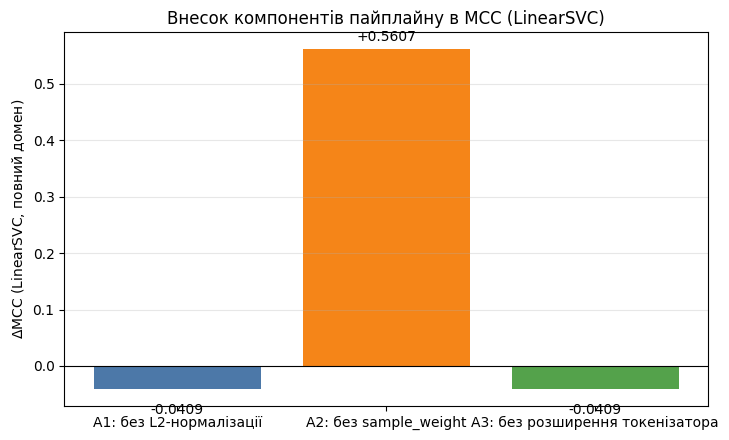

saved: /Users/roman/Personal/dyploma/data/processed/ablation/linearsvc_ablation_deltas.png  (38926 bytes)


In [12]:
lin_deltas = deltas_df.loc['LinearSVC']
labels_ua = [
    'A1: без L2-нормалізації',
    'A2: без sample_weight',
    'A3: без розширення токенізатора',
]
values = [
    float(lin_deltas['A1_no_L2']),
    float(lin_deltas['A2_no_sample_weight']),
    float(lin_deltas['A3_no_extended_tokenizer']),
]

fig, ax = plt.subplots(figsize=(7.5, 4.5))
bars = ax.bar(labels_ua, values, color=['#4C78A8', '#F58518', '#54A24B'])
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel(r'$\Delta$MCC (LinearSVC, повний домен)')
ax.set_title('Внесок компонентів пайплайну в MCC (LinearSVC)')
ax.grid(axis='y', alpha=0.3)

# Annotate each bar with its numeric value.
for bar, v in zip(bars, values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        v + (0.01 if v >= 0 else -0.025),
        f'{v:+.4f}',
        ha='center', va='bottom' if v >= 0 else 'top',
        fontsize=10,
    )

fig.tight_layout()
png_path = RESULTS_DIR / 'linearsvc_ablation_deltas.png'
fig.savefig(png_path, dpi=150)
plt.show()
print(f'saved: {png_path}  ({png_path.stat().st_size} bytes)')

## 10. Інтерпретація

Друкуємо числові підсумки для LinearSVC (головна модель). Інтерпретаційний текст у тезі (розділ «Ablation study») формулюється окремо на основі цих значень.

In [13]:
print('LinearSVC — внесок кожного компонента:')
d_a1 = float(lin_deltas['A1_no_L2'])
d_a2 = float(lin_deltas['A2_no_sample_weight'])
d_a3 = float(lin_deltas['A3_no_extended_tokenizer'])

print(f'  LinearSVC ΔMCC (A1_no_L2)                   = {d_a1:+.4f}')
print(f'  LinearSVC ΔMCC (A2_no_sample_weight)        = {d_a2:+.4f}')
print(f'  LinearSVC ΔMCC (A3_no_extended_tokenizer)   = {d_a3:+.4f}')
print()
print(f'A1 ΔMCC={d_a1:+.4f} → L2-нормалізація вносить {d_a1:+.4f} MCC')
print(f'A2 ΔMCC={d_a2:+.4f} → sample_weight вносить {d_a2:+.4f} MCC')
print(f'A3 ΔMCC={d_a3:+.4f} → розширення токенізатора вносить {d_a3:+.4f} MCC')

LinearSVC — внесок кожного компонента:
  LinearSVC ΔMCC (A1_no_L2)                   = -0.0409
  LinearSVC ΔMCC (A2_no_sample_weight)        = +0.5607
  LinearSVC ΔMCC (A3_no_extended_tokenizer)   = -0.0409

A1 ΔMCC=-0.0409 → L2-нормалізація вносить -0.0409 MCC
A2 ΔMCC=+0.5607 → sample_weight вносить +0.5607 MCC
A3 ΔMCC=-0.0409 → розширення токенізатора вносить -0.0409 MCC


## Висновки

Реалізовано ablation study з трьома варіантами та чотирма моделями. Базова лінія відтворена з нуля з точністю $10^{-6}$ проти `metrics_fb.csv`.

Артефакти:

* `data/processed/ablation/ablation_results.csv` — повна таблиця $16 \times 6$ (4 варіанти × 4 моделі).
* `data/processed/ablation/ablation_deltas.csv` — таблиця $\Delta\mathrm{MCC}$ для кожної моделі та кожного ablation.
* `data/processed/ablation/linearsvc_ablation_deltas.png` — діаграма внеску компонентів для LinearSVC.
* `data/processed/ablation/zookeeper_full_embeddings_vanilla.npy` — ванільні BERT-вектори A3 для відтворюваності.

Числові висновки про роль L2-нормалізації, `sample_weight` і розширення токенізатора передаються у розділ «Ablation study» тези.